# Projeto de Implementação do Fuzzy C-Means

- Enzo Ambrósio (RA: 24008773)
- Giulia Monteiro Garrido (RA: 24010281)
- Thomaz Dacorso (RA: )

## Requisitos

**Requisitos do Projeto:**
1. Implementação e explicação do funcionamento do algoritmo (7pts)

2. Aplicar o algoritmo na base de dados Iris (completa, 4 atributos, 3 classes) e listar as pertinências de cada amostra usando 3 grupos (1pt)

3. Plot de resultados utilizando a base de dados Iris (apenas as amostras virgínica e versicolor) usando 2 grupos. Notem que é importante demonstrar a pertinência intermediária, o que será mais fácil em um problema de binário (2pts)

| **Parâmetros** | **Significado** |
| --- | --- |
| k | N° de grupos |
| m | Fator de difusão/fuzzificação |

| **Fórmulas/Funções** |
| --- |
| Criar pertinências aleatórias |
| Pertinência / w |
| Função objetivo |
| Atualizar centróides |

## Etapa 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist

In [3]:
#distancias = cdist(X, centroids, metric='euclidean')

In [4]:
def generate_random_relevence(X,k):
    
    '''
    Atribui a cada item uma relevância aleatória para cada grupo k.
    Garante que a soma de cada linha seja 1.
    '''

    relevences=[]    
    
    for i in range(len(X)):
        relevences.append([])
        aux=0
        sum=0

        for j in range(k):
            relevences[i].append(np.random.uniform(0,1-aux))
            aux+=relevences[i][j]
            sum+=relevences[i][j]

        if sum!=1:
            relevences[i][0]=1-sum+relevences[i][0]

    return np.array(relevences)
    


In [5]:
def relevence(xi, C, j, m):
    '''
    xi: um vetor de uma amostra
    C: matriz de centróides
    j: número do centróide alvo
    m: parâmetro de fuzziness

    Calcula a pertinência w_ij de xi ao centróide C[j]
    usando cdist para calcular as distâncias euclidianas.
    '''

    # cdist é de matrizes 2D, então fiz o reshape xi para (1, n_features)
    # ai da um o array do shape com a distancia de xi pro centroide

    distancias = cdist(xi.reshape(1, -1), C, metric='euclidean')[0]

    dist_j = distancias[j]

    exponent = 2 / (m - 1)

    sum = 0

    for l in range(len(C)):

        dist_l = distancias[l]

        if dist_l == 0:

            return 1.0 if l == j else 0.0

        sum += (dist_j / dist_l) ** exponent

    return 1 / sum

In [6]:
def centroid_update(X, U, m):

    k = U.shape[1]
    C = []

    for j in range(k):
        numerador = 0
        denominador = 0

        for i in range(len(X)):
            numerador += (U[i][j]**m) * X[i]
            denominador += U[i][j]**m

        C.append(numerador/denominador)
    
    return np.array(C)

In [7]:
def objective_function(X,C,m):

    '''
    X: matriz de dados
    C: matriz de centróides
    m: parâmetro de fuzziness
    Calcula a função objetivo do FCM    
    '''

    n_samples = X.shape[0]
    n_clusters = C.shape[0]
    J = 0
    
    for i in range(n_samples):
        for j in range(n_clusters):
            u_ij = relevence(X[i], C, j, m)
            J += (u_ij ** m) * np.linalg.norm(X[i] - C[j]) ** 2

    return J

In [8]:
def fuzzy_cmeans(X, k, m, max_iter=100, conv = 0.001):

    n_samples = X.shape[0] #n° de linhas

    random_indices = np.random.choice(n_samples, k, replace=False)
    C = X[random_indices].copy() #escolhe k posições aleatórias pra servir de centróides

    U = generate_random_relevence(X, k) #cria a matriz de pertinência aleatória inicial
    
    J_history = []

    for iteration in range(max_iter):
        C_old = C.copy()

        U_new = np.zeros_like(U)

        for i in range(n_samples):
            for j in range(k):
                U_new[i, j] = relevence(X[i], C, j, m)

        U = U_new

        C = centroid_update(X, U, m)
        J = objective_function(X, C, m)

        J_history.append(J)
        convergence = np.linalg.norm(C - C_old)

        if convergence < conv:
            print(f"Convergiu na iteração {iteration}")
            break

    
    return U, C, J_history

## Etapa 2

In [9]:
import seaborn as sns

iris = sns.load_dataset("iris")
X = iris.iloc[:, :4].values # Não usa a coluna 'species'

X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [10]:
U, C, J = fuzzy_cmeans(X, k=3, m=2)

print("Pertinências: \n", np.round(U, 4))
print("Centróides: \n", C)

Convergiu na iteração 12
Pertinências: 
 [[1.100e-03 9.966e-01 2.300e-03]
 [7.500e-03 9.759e-01 1.660e-02]
 [6.400e-03 9.798e-01 1.370e-02]
 [1.010e-02 9.675e-01 2.240e-02]
 [1.800e-03 9.945e-01 3.800e-03]
 [2.060e-02 9.346e-01 4.480e-02]
 [6.500e-03 9.795e-01 1.400e-02]
 [1.000e-04 9.995e-01 3.000e-04]
 [2.190e-02 9.304e-01 4.770e-02]
 [5.300e-03 9.827e-01 1.190e-02]
 [1.020e-02 9.681e-01 2.170e-02]
 [2.400e-03 9.921e-01 5.400e-03]
 [9.200e-03 9.707e-01 2.020e-02]
 [2.520e-02 9.230e-01 5.180e-02]
 [3.760e-02 8.898e-01 7.260e-02]
 [5.430e-02 8.414e-01 1.043e-01]
 [1.750e-02 9.470e-01 3.560e-02]
 [1.100e-03 9.967e-01 2.300e-03]
 [3.030e-02 9.042e-01 6.550e-02]
 [6.700e-03 9.792e-01 1.410e-02]
 [9.500e-03 9.686e-01 2.180e-02]
 [4.800e-03 9.848e-01 1.040e-02]
 [1.380e-02 9.587e-01 2.750e-02]
 [6.100e-03 9.795e-01 1.440e-02]
 [9.800e-03 9.670e-01 2.320e-02]
 [8.000e-03 9.736e-01 1.840e-02]
 [1.600e-03 9.949e-01 3.600e-03]
 [2.100e-03 9.934e-01 4.600e-03]
 [2.000e-03 9.937e-01 4.300e-03]
 [

## Etapa 3

In [11]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
filtered_iris = iris[iris['species']!='setosa']
X = filtered_iris.iloc[:, :4].values

In [13]:
#filtered_iris['species'].values

In [ ]:
U, C, J = fuzzy_cmeans(X, k=2, m=2)

Convergiu na iteração 9


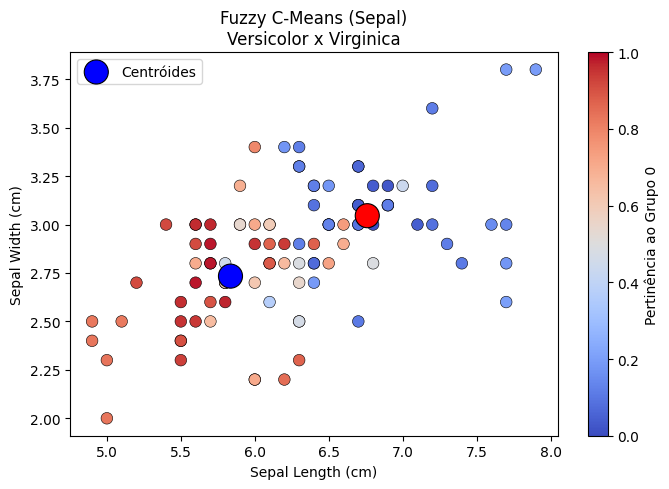

In [22]:
membership = U[:, 0]

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 0], X[:, 1],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 0], C[:, 1], marker='o', s=300, c=['blue', 'red'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Fuzzy C-Means (Sepal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()

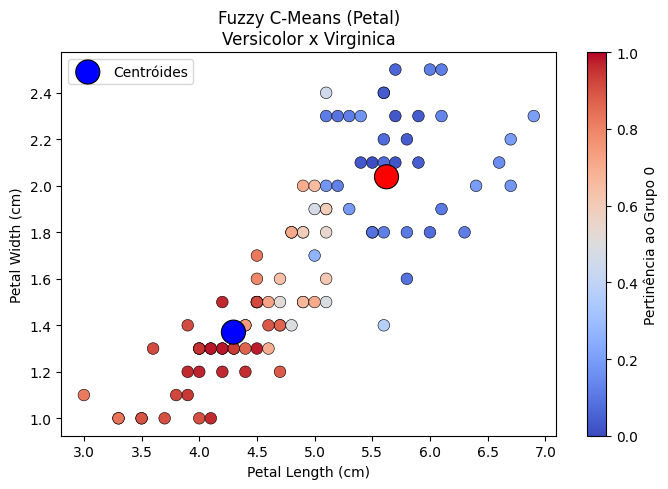

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 2], X[:, 3],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 2], C[:, 3], marker='o', s=300, c=['blue', 'red'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Fuzzy C-Means (Petal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()